In [ ]:

import os, random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tensorflow.keras import layers, models


In [52]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_ROOT = r"D:\\E0323036-SEM6\\dl_med\\Dataset_BUSI_with_GT"
CLASSES = ["benign", "malignant", "normal"]
IMG_SIZE = 224
BATCH_SIZE = 8
EPOCHS = 20
AUTOTUNE = tf.data.AUTOTUNE

print("GPUs:", tf.config.list_physical_devices("GPU"))

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Total images: 780


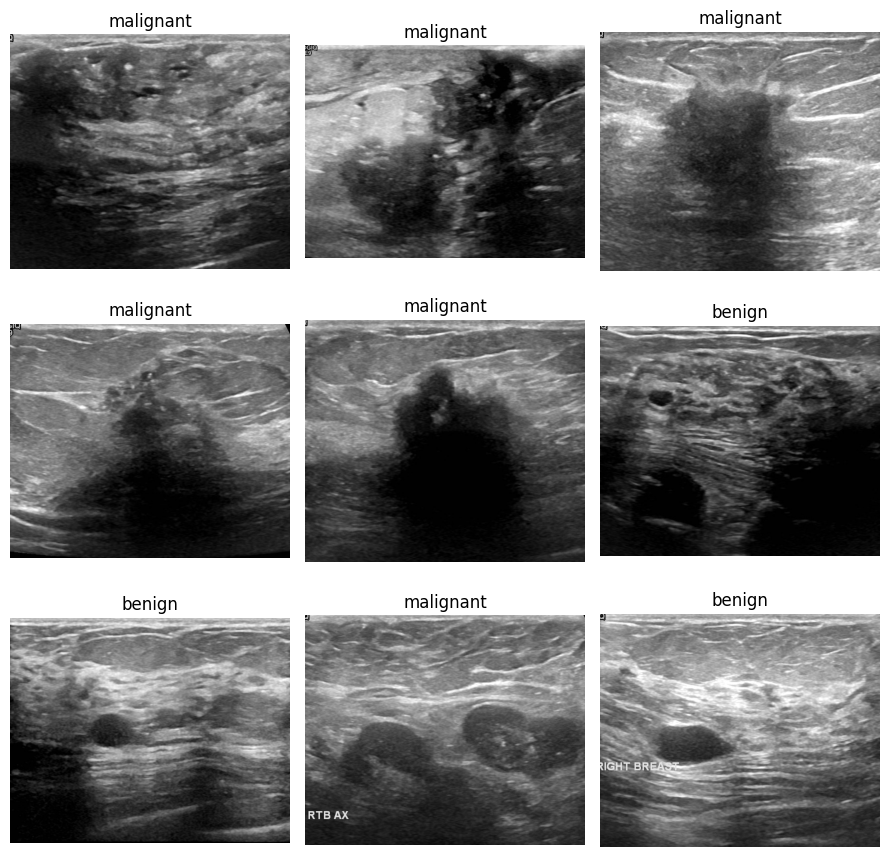

In [16]:
def is_image(fname):
    return fname.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")) and "_mask" not in fname.lower()

def collect_files(root, classes):
    paths, labels = [], []
    for idx, cls in enumerate(classes):
        cls_dir = os.path.join(root, cls)
        for f in os.listdir(cls_dir):
            if is_image(f):
                paths.append(os.path.join(cls_dir, f))
                labels.append(idx)
    return np.array(paths), np.array(labels)

paths, labels = collect_files(DATA_ROOT, CLASSES)
print("Total images:", len(paths))

# ---------------------------
# 1a. randomly display 9 images with their labels
idxs = np.random.choice(len(paths), 9, replace=False)
plt.figure(figsize=(9,9))
for i, idx in enumerate(idxs):
    img = tf.io.read_file(paths[idx])
    img = tf.image.decode_image(img, channels=1)
    plt.subplot(3,3,i+1)
    plt.imshow(tf.squeeze(img), cmap="gray")
    plt.title(CLASSES[labels[idx]])
    plt.axis("off")
plt.tight_layout()
plt.show()

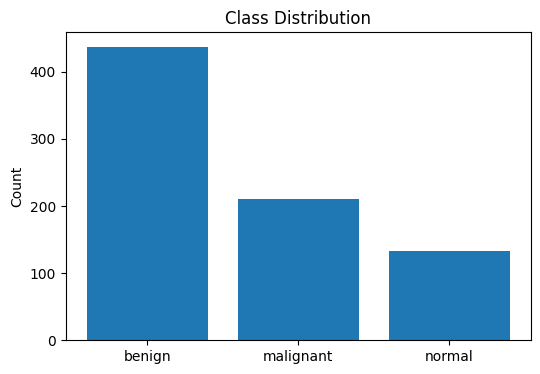

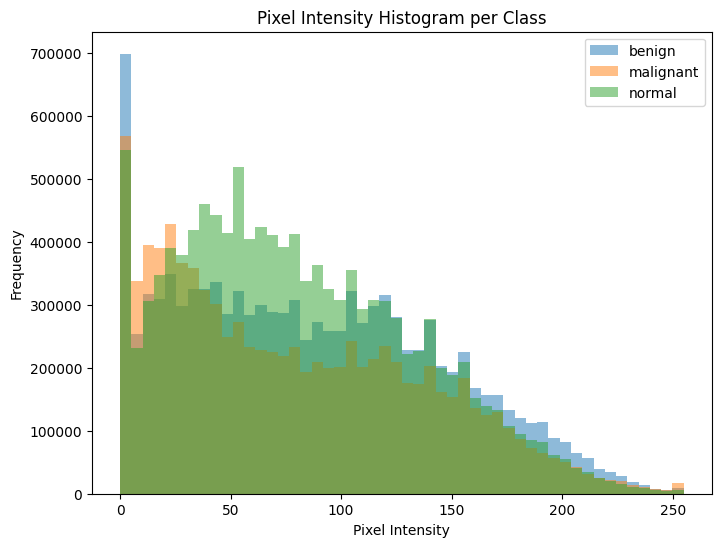

benign mean/std: 0.3390, 0.2221
malignant mean/std: 0.3114, 0.2242
normal mean/std: 0.3198, 0.2116
Global mean/std: 0.3234, 0.2193


In [17]:
counts = [np.sum(labels==i) for i in range(len(CLASSES))]
plt.figure(figsize=(6,4))
plt.bar(CLASSES, counts)
plt.title("Class Distribution")
plt.ylabel("Count")
plt.show()
# 1c. Pixel intensity hist per class
plt.figure(figsize=(8,6))
for cls_idx, cls_name in enumerate(CLASSES):
    cls_paths = paths[labels==cls_idx]
    sample = np.random.choice(len(cls_paths), min(30, len(cls_paths)), replace=False)
    pixels = []
    for i in sample:
        img = tf.io.read_file(cls_paths[i])
        img = tf.image.decode_image(img, channels=1)
        pixels.extend(tf.reshape(img, [-1]).numpy())
    plt.hist(pixels, bins=50, alpha=0.5, label=cls_name)
plt.legend()
plt.title("Pixel Intensity Histogram per Class")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()
# 1d. Mean/Std per class
def mean_std(paths_subset):
    all_pixels = []
    for p in paths_subset:
        img = tf.io.read_file(p)
        img = tf.image.decode_image(img, channels=1)
        img = tf.image.convert_image_dtype(img, tf.float32)
        all_pixels.append(tf.reshape(img, [-1]).numpy())
    all_pixels = np.concatenate(all_pixels)
    return all_pixels.mean(), all_pixels.std()

class_stats = {}
for i, cls in enumerate(CLASSES):
    cls_paths = paths[labels==i]
    m, s = mean_std(cls_paths)
    class_stats[cls] = (m, s)
    print(f"{cls} mean/std: {m:.4f}, {s:.4f}")

global_mean = np.mean([v[0] for v in class_stats.values()])
global_std = np.mean([v[1] for v in class_stats.values()])
print(f"Global mean/std: {global_mean:.4f}, {global_std:.4f}")


In [59]:
import tensorflow as tf

# Ensure AUTOTUNE is available
AUTOTUNE = tf.data.AUTOTUNE

# ---------------------------------------------------------
# 2. DATA PIPELINE (UPDATED FOR EFFICIENTNET - 3 CHANNELS)
# ---------------------------------------------------------

# Note: If your global_mean/std were calculated for 1 channel, 
# TensorFlow will automatically broadcast them across all 3 channels here.
global_mean_tf = tf.constant(global_mean, dtype=tf.float32)
global_std_tf  = tf.constant(global_std, dtype=tf.float32)

def decode_resize(path, label):
    # 1. Read file
    img = tf.io.read_file(path)
    
    # 2. Decode image - CHANGED TO 3 CHANNELS FOR EFFICIENTNET
    # Even if your images are grayscale, this will repeat the channel 3 times (R=G=B)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    
    # 3. Set Shape (Height, Width, 3)
    img.set_shape([None, None, 3]) 
    
    # 4. Resize
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    
    # 5. Convert to float32 [0, 1]
    img = tf.image.convert_image_dtype(img, tf.float32)
    
    return img, label

def normalize(img, label):
    # Standardize
    img = (img - global_mean_tf) / global_std_tf
    return img, label

# Create base dataset
data = tf.data.Dataset.from_tensor_slices((paths, labels))
data = data.shuffle(len(paths), seed=SEED)

# Split datasets
n_total = len(paths)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)
# Split
train_ds = data.take(n_train)
rest = data.skip(n_train)
val_ds = rest.take(n_val)
test_ds = rest.skip(n_val)

# 3. AUGMENTATION (CLEANED UP & OPTIMIZED)
# Combined redundant layers into single powerful transformations
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.3),     # Increased range
    tf.keras.layers.RandomZoom(0.3),         # Increased range
    tf.keras.layers.RandomContrast(0.3),
    tf.keras.layers.RandomBrightness(0.3),
    tf.keras.layers.RandomTranslation(0.2, 0.2),
    tf.keras.layers.GaussianNoise(0.01),     # Helps with generalization
])

def augment_fn(img, label):
    return augment(img, training=True), label

# --- FINAL PIPELINE ---

train_ds = (train_ds
            .map(decode_resize, num_parallel_calls=AUTOTUNE)
            .map(augment_fn, num_parallel_calls=AUTOTUNE) # Augmentation before Normalization
            .map(normalize, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

val_ds = (val_ds
          .map(decode_resize, num_parallel_calls=AUTOTUNE)
          .map(normalize, num_parallel_calls=AUTOTUNE)
          .batch(BATCH_SIZE)
          .prefetch(AUTOTUNE))

test_ds = (test_ds
           .map(decode_resize, num_parallel_calls=AUTOTUNE)
           .map(normalize, num_parallel_calls=AUTOTUNE)
           .batch(BATCH_SIZE)
           .prefetch(AUTOTUNE))

Model: "sequential_40"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_54 (Conv2D)          (None, 224, 224, 32)      896       
                                                                 
 max_pooling2d_54 (MaxPoolin  (None, 112, 112, 32)     0         
 g2D)                                                            
                                                                 
 conv2d_55 (Conv2D)          (None, 112, 112, 64)      18496     
                                                                 
 max_pooling2d_55 (MaxPoolin  (None, 56, 56, 64)       0         
 g2D)                                                            
                                                                 
 conv2d_56 (Conv2D)          (None, 56, 56, 128)       73856     
                                                                 
 max_pooling2d_56 (MaxPoolin  (None, 28, 28, 128)    

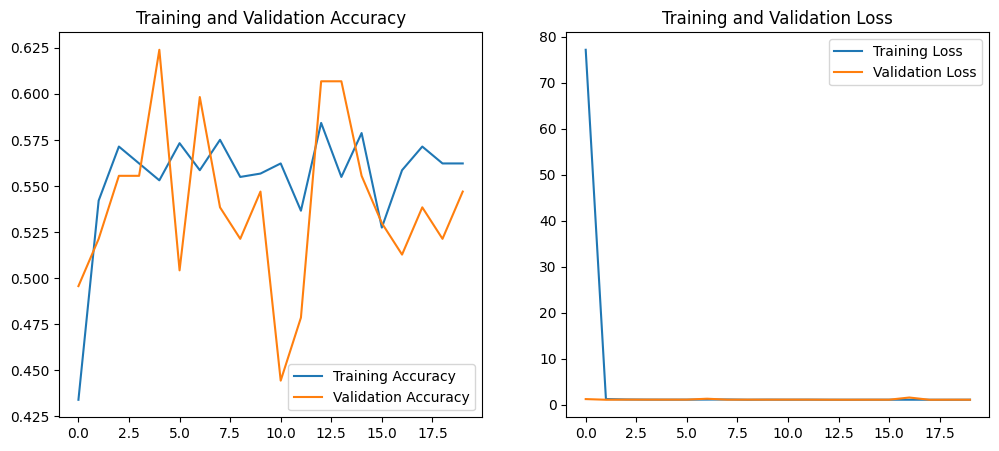

15/15 [==============================] - 0s 6ms/step - loss: 1.0623 - accuracy: 0.5641

Simple CNN Test Accuracy: 56.41%


In [61]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# ---------------------------
# 3. MODEL DEFINITION (FIXED FOR 3 CHANNELS)
# ---------------------------
def build_model(num_classes=3):
    model = models.Sequential([
        # CHANGED: Input shape now has 3 channels to match the data pipeline
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        
        # Feature Extraction (CNN)
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Classifier
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

# Initialize Model
model = build_model(num_classes=3)

# Compile Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ---------------------------
# 4. TRAINING
# ---------------------------
EPOCHS = 20 # Updated to 20 as per your snippet

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

# ---------------------------
# 5. EVALUATION & PLOTTING
# ---------------------------
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    
    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    
    plt.show()

plot_history(history)

# Final Test Evaluation
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nSimple CNN Test Accuracy: {test_acc*100:.2f}%")

1/1 [==============================] - 1s 788ms/step


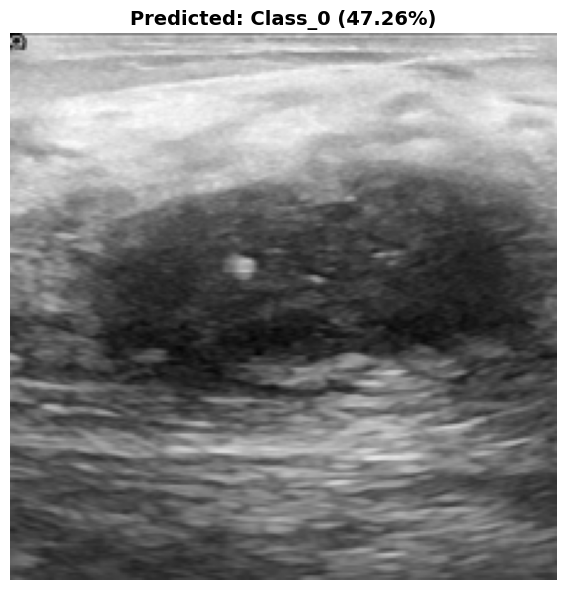


Image: D:\E0323036-SEM6\dl_med\Dataset_BUSI_with_GT\malignant\malignant (1).png
Predicted Class: 0
Confidence: 47.26%

All Class Probabilities:
  Class_0: 47.26%
  Class_1: 39.27%
  Class_2: 13.47%



In [85]:
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# ---------------------------
# TESTING A SINGLE IMAGE
# ---------------------------

def test_single_image(image_path, model, class_names=None):
    """
    Test the model on a single image
    
    Args:
        image_path (str): Path to the image file
        model: Your trained model
        class_names (list): List of class names (e.g., ['class0', 'class1', 'class2'])
    """
    
    # Load and preprocess the image
    img = Image.open(image_path).convert('RGB')  # Ensure 3 channels
    img = img.resize((IMG_SIZE, IMG_SIZE))  # Resize to match training size
    img_array = np.array(img) / 255.0  # Normalize to [0, 1]
    
    # Add batch dimension
    img_batch = np.expand_dims(img_array, axis=0)
    
    # Make prediction
    predictions = model.predict(img_batch)
    predicted_class = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class]
    
    # Display results
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis('off')
    
    if class_names:
        title = f"Predicted: {class_names[predicted_class]} ({confidence*100:.2f}%)"
    else:
        title = f"Predicted Class: {predicted_class} (Confidence: {confidence*100:.2f}%)"
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print detailed predictions
    print(f"\n{'='*50}")
    print(f"Image: {image_path}")
    print(f"{'='*50}")
    print(f"Predicted Class: {predicted_class}")
    print(f"Confidence: {confidence*100:.2f}%")
    print(f"\nAll Class Probabilities:")
    for i, prob in enumerate(predictions[0]):
        class_label = class_names[i] if class_names else f"Class {i}"
        print(f"  {class_label}: {prob*100:.2f}%")
    print(f"{'='*50}\n")
    
    return predicted_class, confidence, predictions[0]

# ---------------------------
# USAGE EXAMPLE
# ---------------------------

# Define your class names (update these based on your classes)
class_names = ['Class_0', 'Class_1', 'Class_2']  # Change these to your actual class names

# Test on a single image
image_path = 'D:\\E0323036-SEM6\\dl_med\\Dataset_BUSI_with_GT\\malignant\\malignant (1).png'  # Change to your image path

predicted_class, confidence, all_probs = test_single_image(
    image_path=image_path,
    model=model,
    class_names=class_names
)

In [82]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

# --- 1. MODEL DEFINITION (EfficientNet-B0) ---

# FIX: Convert the Tensor to a numpy array first to count unique classes
if isinstance(labels, tf.Tensor):
    num_classes = len(np.unique(labels.numpy()))
else:
    num_classes = len(np.unique(labels))

print(f"Number of classes: {num_classes}")

# Create the base model
# include_top=False removes the final 1000-class ImageNet layer
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet', 
    input_shape=(IMG_SIZE, IMG_SIZE, 3) # Matches your 3-channel pipeline
)

# Freeze the base model (Transfer Learning)
base_model.trainable = False 

# Build the final model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

# --- 2. COMPILATION ---

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

model.summary()

# --- 3. TRAINING ---

EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Number of classes: 3
Model: "sequential_47"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   
                                                                 
 global_average_pooling2d_11  (None, 1280)             0         
  (GlobalAveragePooling2D)                                       
                                                                 
 batch_normalization_10 (Bat  (None, 1280)             5120      
 chNormalization)                                                
                                                                 
 dropout_32 (Dropout)        (None, 1280)              0         
                                                                 
 dense_53 (Dense)            (None, 3)                 3843      
                                                                 
Total params: 4,058,534
Trainabl

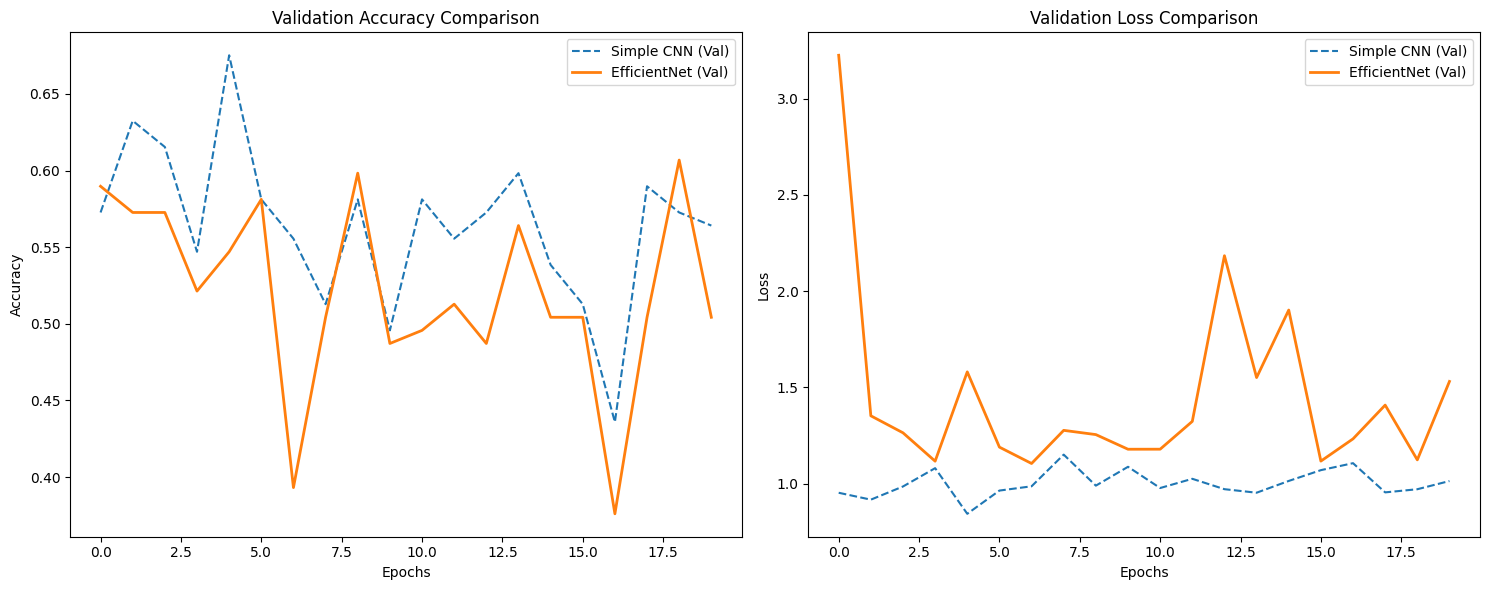

In [83]:
def plot_comparison(hist1, hist2):
    plt.figure(figsize=(15, 6))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(hist1.history['val_accuracy'], label='Simple CNN (Val)', linestyle='--')
    plt.plot(hist2.history['val_accuracy'], label='EfficientNet (Val)', linewidth=2)
    plt.title('Validation Accuracy Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(hist1.history['val_loss'], label='Simple CNN (Val)', linestyle='--')
    plt.plot(hist2.history['val_loss'], label='EfficientNet (Val)', linewidth=2)
    plt.title('Validation Loss Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_comparison(history, eff_history)


--- CLASSIFICATION REPORT (EfficientNet-B0) ---
              precision    recall  f1-score   support

     Class 0       0.62      0.89      0.73        74
     Class 1       0.00      0.00      0.00        25
     Class 2       0.20      0.11      0.14        18

    accuracy                           0.58       117
   macro avg       0.27      0.33      0.29       117
weighted avg       0.42      0.58      0.49       117



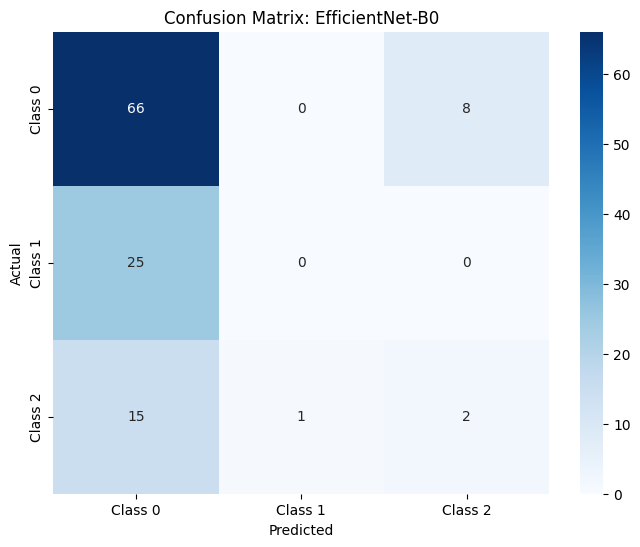

In [84]:
# 1. Get true labels and predictions
y_true = []
y_pred = []

for x, y in test_ds:
    preds = eff_model.predict(x, verbose=0)
    y_true.extend(y.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# 2. Classification Report
target_names = ['Class 0', 'Class 1', 'Class 2'] # Replace with your actual labels
print("\n--- CLASSIFICATION REPORT (EfficientNet-B0) ---")
print(classification_report(y_true, y_pred, target_names=target_names))

# 3. Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: EfficientNet-B0')
plt.show()